In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

%matplotlib inline

In [82]:
df = pd.read_csv("./spam.csv", encoding="latin-1")

df = df[["v1", "v2"]]
df.columns = ["label", "message"]

df = df.dropna()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [83]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [84]:
X_text = df["message"]
y = df["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4457
Testing samples: 1115


In [85]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (4457, 5000)
Testing shape: (1115, 5000)


In [87]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0

            for xi, target in zip(X, y):
                score = np.dot(xi, self.weights) + self.bias
                prediction = 1 if score >= 0 else 0

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

    def predict(self, X):
        scores = np.dot(X, self.weights) + self.bias
        return np.where(scores >= 0, 1, 0)

In [88]:
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=20
)

perceptron.fit(X_train, y_train)

perceptron_pred = perceptron.predict(X_test)

perceptron_accuracy = np.mean(
    perceptron_pred == y_test
)

print(f"Perceptron accuracy: {perceptron_accuracy:.4f}")

Perceptron accuracy: 0.9848


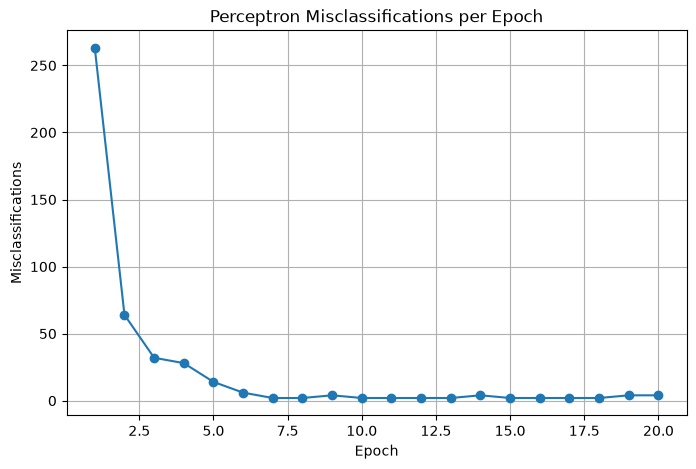

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(perceptron.errors) + 1),
    perceptron.errors,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title("Perceptron Misclassifications per Epoch")
plt.grid(True)
plt.show()

In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train)

print("2D shape:", X_train_2d.shape)

2D shape: (4457, 2)


In [91]:
def plot_boundary(X, y, weights, bias, title):

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Ham",
        alpha=0.5
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Spam",
        alpha=0.5
    )

    x_values = np.linspace(
        X[:, 0].min(),
        X[:, 0].max(),
        100
    )

    if abs(weights[1]) > 1e-10:
        y_values = (
            -(weights[0] * x_values + bias)
            / weights[1]
        )

        plt.plot(
            x_values,
            y_values,
            linewidth=2,
            label="Decision Boundary"
        )

    plt.xlabel("TF-IDF Feature 1")
    plt.ylabel("TF-IDF Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [92]:
perceptron_2d = Perceptron(
    learning_rate=0.01,
    epochs=10
)

perceptron_2d.fit(X_train_2d, y_train)

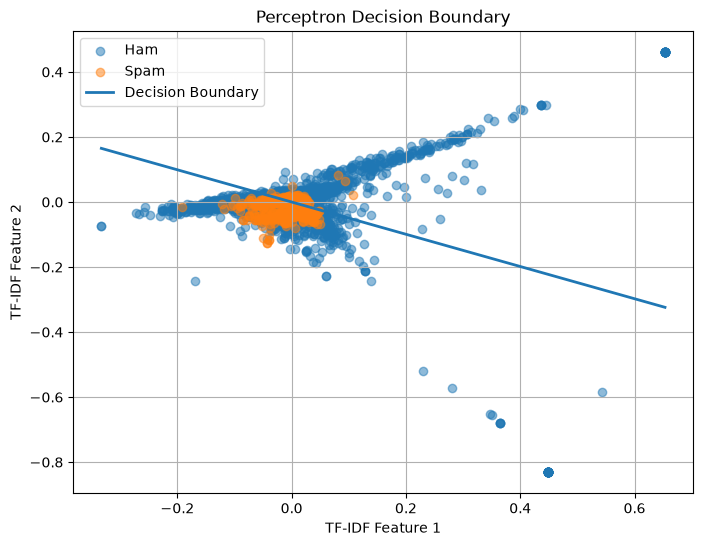

In [93]:
plot_boundary(
    X_train_2d,
    y_train,
    perceptron_2d.weights,
    perceptron_2d.bias,
    "Perceptron Decision Boundary"
)

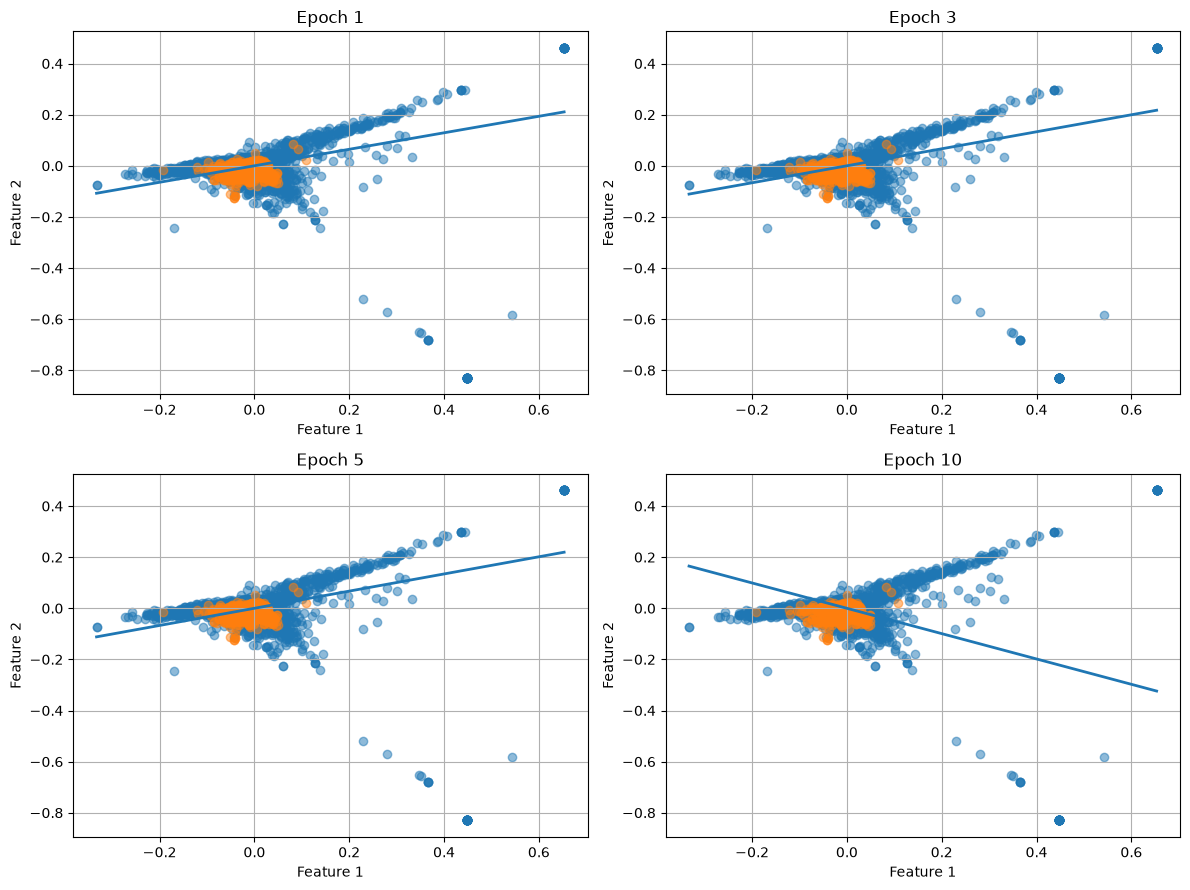

In [94]:
epochs_to_show = [0, 2, 4, 9]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9)
)

for ax, epoch in zip(axes.ravel(), epochs_to_show):

    weights = perceptron_2d.weight_history[epoch]
    bias = perceptron_2d.bias_history[epoch]

    ax.scatter(
        X_train_2d[y_train == 0, 0],
        X_train_2d[y_train == 0, 1],
        label="Ham",
        alpha=0.5
    )

    ax.scatter(
        X_train_2d[y_train == 1, 0],
        X_train_2d[y_train == 1, 1],
        label="Spam",
        alpha=0.5
    )

    x_values = np.linspace(
        X_train_2d[:, 0].min(),
        X_train_2d[:, 0].max(),
        100
    )

    if abs(weights[1]) > 1e-10:
        y_values = (
            -(weights[0] * x_values + bias)
            / weights[1]
        )

        ax.plot(
            x_values,
            y_values,
            linewidth=2
        )

    ax.set_title(f"Epoch {epoch + 1}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [95]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.05, epochs=500):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def cost(self, y, probabilities):
        epsilon = 1e-15
        probabilities = np.clip(probabilities, epsilon, 1 - epsilon)

        return -np.mean(
            y * np.log(probabilities)
            + (1 - y) * np.log(1 - probabilities)
        )

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            z = np.dot(X, self.weights) + self.bias
            probabilities = self.sigmoid(z)

            current_cost = self.cost(y, probabilities)
            self.cost_history.append(current_cost)

            dw = np.dot(X.T, probabilities - y) / n_samples
            db = np.mean(probabilities - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_probability(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_probability(X)

        return np.where(probabilities >= threshold, 1, 0)

In [96]:
logistic = LogisticRegressionScratch(
    learning_rate=0.05,
    epochs=500
)

logistic.fit(X_train, y_train)

logistic_probabilities = logistic.predict_probability(X_test)

logistic_pred = logistic.predict(
    X_test,
    threshold=0.5
)

logistic_accuracy = np.mean(
    logistic_pred == y_test
)

print(f"Logistic Regression accuracy: {logistic_accuracy:.4f}")

Logistic Regression accuracy: 0.8664


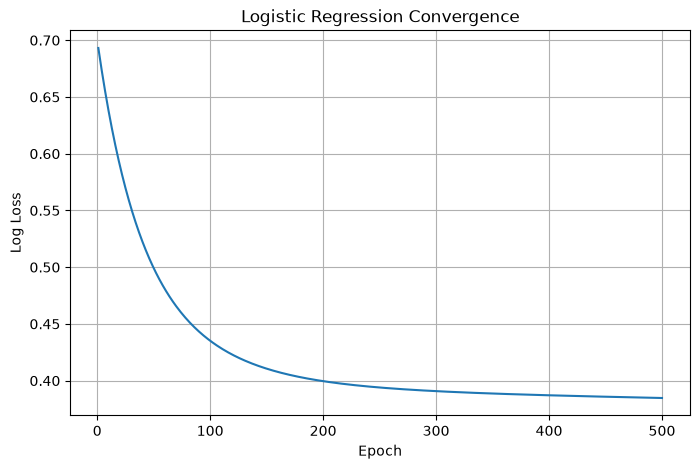

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(logistic.cost_history) + 1),
    logistic.cost_history
)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Logistic Regression Convergence")
plt.grid(True)
plt.show()

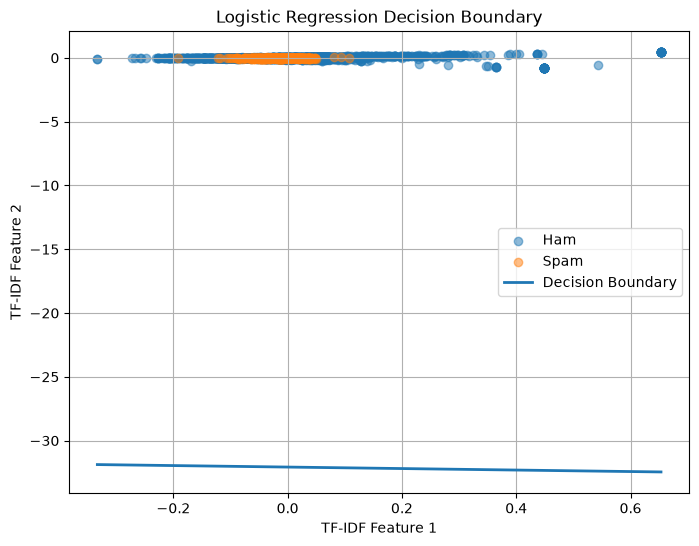

In [98]:
logistic_2d = LogisticRegressionScratch(
    learning_rate=0.05,
    epochs=500
)

logistic_2d.fit(X_train_2d, y_train)

plot_boundary(
    X_train_2d,
    y_train,
    logistic_2d.weights,
    logistic_2d.bias,
    "Logistic Regression Decision Boundary"
)

In [99]:
comparison = pd.DataFrame({
    "Model": [
        "Perceptron",
        "Logistic Regression"
    ],
    "Accuracy": [
        perceptron_accuracy,
        logistic_accuracy
    ]
})

comparison

,Model,Accuracy
0,Perceptron,0.984753
1,Logistic Regression,0.866368


In [100]:
def confusion_values(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN


def calculate_metrics(y_true, y_pred):

    TP, TN, FP, FN = confusion_values(
        y_true,
        y_pred
    )

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = (
        TP / (TP + FP)
        if TP + FP > 0 else 0
    )

    recall = (
        TP / (TP + FN)
        if TP + FN > 0 else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0 else 0
    )

    return {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [101]:
perceptron_metrics = calculate_metrics(
    y_test,
    perceptron_pred
)

pd.Series(perceptron_metrics)

TP           136.000000
TN           962.000000
FP             4.000000
FN            13.000000
Accuracy       0.984753
Precision      0.971429
Recall         0.912752
F1-score       0.941176
dtype: float64

In [102]:
logistic_metrics = calculate_metrics(
    y_test,
    logistic_pred
)

pd.Series(logistic_metrics)

TP             0.000000
TN           966.000000
FP             0.000000
FN           149.000000
Accuracy       0.866368
Precision      0.000000
Recall         0.000000
F1-score       0.000000
dtype: float64

In [103]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Perceptron": [
        perceptron_metrics["Accuracy"],
        perceptron_metrics["Precision"],
        perceptron_metrics["Recall"],
        perceptron_metrics["F1-score"]
    ],
    "Logistic Regression": [
        logistic_metrics["Accuracy"],
        logistic_metrics["Precision"],
        logistic_metrics["Recall"],
        logistic_metrics["F1-score"]
    ]
})

final_comparison

,Metric,Perceptron,Logistic Regression
0,Accuracy,0.984753,0.866368
1,Precision,0.971429,0.000000
2,Recall,0.912752,0.000000
3,F1-score,0.941176,0.000000


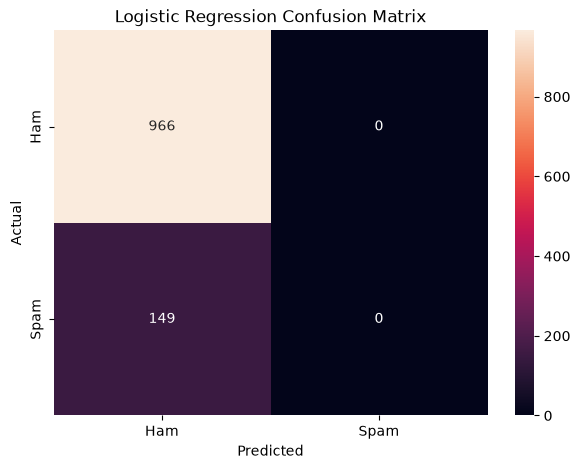

In [104]:
TP, TN, FP, FN = confusion_values(
    y_test,
    logistic_pred
)

cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [105]:
def roc_from_scratch(y_true, probabilities):

    thresholds = np.linspace(0, 1, 101)

    fpr = []
    tpr = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        TP, TN, FP, FN = confusion_values(
            y_true,
            predictions
        )

        true_positive_rate = (
            TP / (TP + FN)
            if TP + FN > 0 else 0
        )

        false_positive_rate = (
            FP / (FP + TN)
            if FP + TN > 0 else 0
        )

        tpr.append(true_positive_rate)
        fpr.append(false_positive_rate)

    return np.array(fpr), np.array(tpr)

In [106]:
fpr, tpr = roc_from_scratch(
    y_test,
    logistic_probabilities
)

order = np.argsort(fpr)

fpr_sorted = fpr[order]
tpr_sorted = tpr[order]

auc = np.trapezoid(
    tpr_sorted,
    fpr_sorted
)

print(f"ROC AUC: {auc:.4f}")

ROC AUC: 0.7925


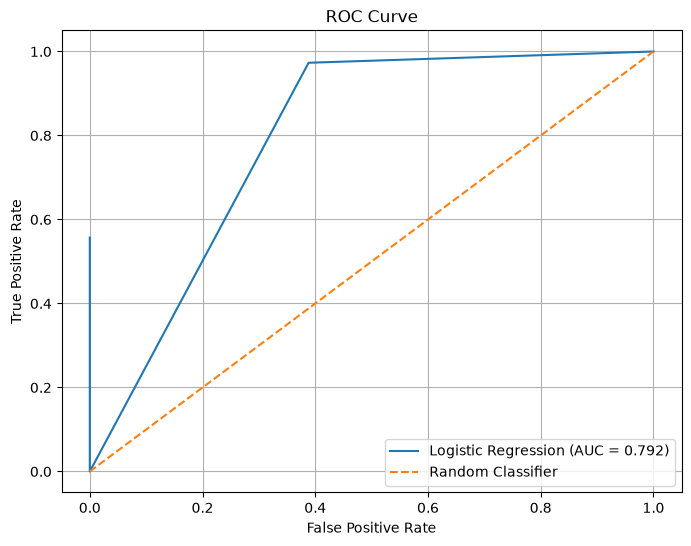

In [107]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_sorted,
    tpr_sorted,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

In [108]:
thresholds = [0.3, 0.5, 0.7]

threshold_results = []

for threshold in thresholds:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    metrics = calculate_metrics(
        y_test,
        predictions
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-score": metrics["F1-score"]
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.866368,0,0.0,0
1,0.5,0.866368,0,0.0,0
2,0.7,0.866368,0,0.0,0


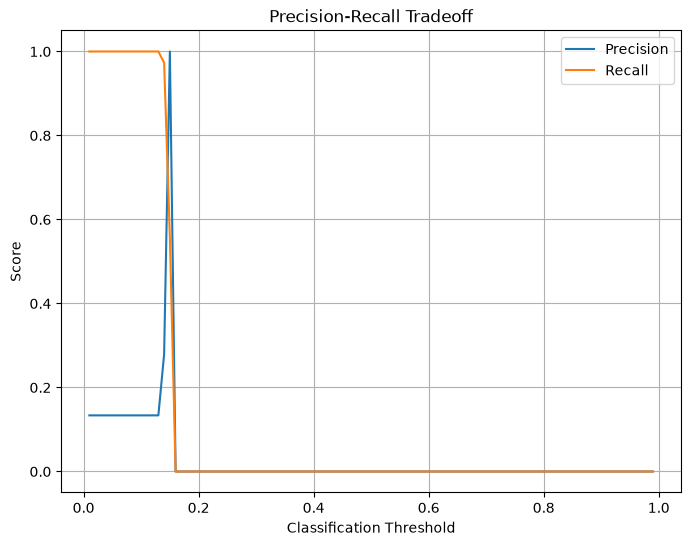

In [109]:
threshold_range = np.linspace(
    0.01,
    0.99,
    99
)

precision_values = []
recall_values = []

for threshold in threshold_range:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    metrics = calculate_metrics(
        y_test,
        predictions
    )

    precision_values.append(
        metrics["Precision"]
    )

    recall_values.append(
        metrics["Recall"]
    )

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_range,
    precision_values,
    label="Precision"
)

plt.plot(
    threshold_range,
    recall_values,
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.grid(True)

plt.show()

In [110]:
f1_values = []

for threshold in threshold_range:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    metrics = calculate_metrics(
        y_test,
        predictions
    )

    f1_values.append(
        metrics["F1-score"]
    )

best_index = np.argmax(f1_values)

best_threshold = threshold_range[best_index]
best_f1 = f1_values[best_index]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")

Best threshold: 0.15
Best F1-score: 0.7155


In [111]:
threshold_df.sort_values(
    by="F1-score",
    ascending=False
)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.866368,0,0.0,0
1,0.5,0.866368,0,0.0,0
2,0.7,0.866368,0,0.0,0


In [112]:
print("Final Results")
print("-" * 40)

print(f"Perceptron Accuracy: {perceptron_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression AUC: {auc:.4f}")
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")

Final Results
----------------------------------------
Perceptron Accuracy: 0.9848
Logistic Regression Accuracy: 0.8664
Logistic Regression AUC: 0.7925
Best Threshold: 0.15
Best F1-score: 0.7155
